# Online Retail II — Exploration & Qualité des Données

Ce notebook a pour objectifs :

1. **Fiche synthétique du dataset**
2. **Dictionnaire des variables**
3. **Analyse de la qualité des données** (NA, doublons, retours, granularité…)
4. **Premiers graphiques exploratoires** :
   - Distributions
   - Saisonnalités
   - Courbe de CA
   - Répartition pays
   - Premiers aperçus cohortes & RFM
5. **Interprétations business** pour chaque graphique

Ces analyses serviront de base :

- aux modules analytiques (cohortes, RFM, CLV),
- puis à l’application Streamlit d’aide à la décision marketing.


In [5]:
# Imports principaux
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Config affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Style graphique
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Seed pour reproductibilité (si on fait des échantillons plus tard)
np.random.seed(42)


In [15]:
from pathlib import Path

PROJECT_ROOT = Path().resolve()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "online_retail_II.csv"

print("Chemin utilisé :", DATA_PATH)
print("Existe :", DATA_PATH.exists())

df_raw = pd.read_csv(DATA_PATH)

print("Dimensions du dataset brut :", df_raw.shape)
df_raw.head()


Chemin utilisé : C:\Users\Antoine\PycharmProjects\DataViz\data\raw\online_retail_II.csv
Existe : True
Dimensions du dataset brut : (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## A — Fiche synthétique du dataset

**Source :**
UCI Machine Learning Repository — Online Retail II (e-commerce B2B non-store online retail).
Transactions de ventes en ligne d’un e-commerçant basé au Royaume-Uni.

**Périmètre temporel :**

- Deux années de données (24 mois) issues des feuilles Excel (ex. `Year 2009-2010`, `Year 2010-2011`).
- Granularité temporelle : **à la minute** via la variable `InvoiceDate`.

**Granularité des lignes :**

- 1 ligne = 1 détail de facture (Invoice line item) :
  - une facture (`Invoice`) peut contenir plusieurs lignes,
  - une ligne correspond à un `StockCode` donné, une `Quantity` et un `Price`.

**Logique business clé :**

- `Quantity > 0` : vente (unités positives)
- `Quantity < 0` : **retour** / annulation de produits
  - Dans ce fichier, il n’y a pas de préfixe "C" dans `Invoice` pour les retours.
- `Price` = **prix unitaire**.
- **Valeur transactionnelle de la ligne** = `Quantity * Price`.
- `Customer ID` identifie un client B2B, avec des **valeurs manquantes** à exclure pour les analyses client.
- `Country` indique le pays du client, avec le **Royaume-Uni (UK)** comme pays dominant.

Ces caractéristiques sont essentielles pour :

- définir les cohortes d’acquisition mensuelles,
- calculer les indicateurs de RFM,
- estimer la CLV et simuler différents scénarios.


In [19]:
df = df_raw.copy()

# Normalisation des noms de colonnes (par sécurité)
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.rename(
    columns={
        "InvoiceDate": "InvoiceDate",
        "Customer_ID": "Customer_ID",
        "StockCode": "StockCode",
        "Price": "Price"
    },
    inplace=True
)

# Conversion des types
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Création de variables dérivées
df["Revenue"] = df["Quantity"] * df["Price"]
df["is_return"] = df["Quantity"] < 0

# Cohorte d'acquisition mensuelle (préparation pour plus tard)
df["InvoiceYearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Indicateur "ligne client valide" pour les analyses client
df["has_customer"] = ~df["Customer_ID"].isna()

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Revenue,is_return,InvoiceYearMonth,has_customer
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40,False,2009-12,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,False,2009-12,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,False,2009-12,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80,False,2009-12,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00,False,2009-12,True


In [20]:
n_rows, n_cols = df.shape
n_customers = df.loc[df["has_customer"], "Customer_ID"].nunique()
n_invoices = df["Invoice"].nunique()
n_products = df["StockCode"].nunique()
n_countries = df["Country"].nunique()

date_min = df["InvoiceDate"].min()
date_max = df["InvoiceDate"].max()

total_revenue = df["Revenue"].sum()
total_revenue_excl_returns = df.loc[~df["is_return"], "Revenue"].sum()

summary = pd.DataFrame(
    {
        "Indicteur": [
            "Nombre de lignes",
            "Nombre de colonnes",
            "Nombre de clients (Customer_ID non NA)",
            "Nombre de factures (Invoice)",
            "Nombre de produits (StockCode)",
            "Nombre de pays (Country)",
            "Première date de transaction",
            "Dernière date de transaction",
            "CA total (incl. retours)",
            "CA total (ventes uniquement)"
        ],
        "Valeur": [
            n_rows,
            n_cols,
            n_customers,
            n_invoices,
            n_products,
            n_countries,
            date_min,
            date_max,
            total_revenue,
            total_revenue_excl_returns
        ],
    }
)

summary


,Indicteur,Valeur
0,Nombre de lignes,1067371
1,Nombre de colonnes,12
2,Nombre de clients (Customer_ID non NA),5942
3,Nombre de factures (Invoice),53628
4,Nombre de produits (StockCode),5305
5,Nombre de pays (Country),43
6,Première date de transaction,2009-12-01 07:45:00
7,Dernière date de transaction,2011-12-09 12:50:00
8,CA total (incl. retours),"19,287,250.57"
9,CA total (ventes uniquement),"20,814,292.00"


### Interprétation — Fiche synthétique

- Le dataset contient un volume conséquent de lignes, ce qui est **adapté à des analyses de cohortes** sur 24 mois.
- Le nombre de **clients avec `Customer_ID` non manquant** permet de construire des vues RFM et CLV robustes, après exclusion des NA.
- Le **nombre de produits** et de **factures** indique une activité soutenue, typique d’un e-commerçant B2B.
- La fenêtre temporelle [première date, dernière date] confirme la présence de **24 mois consécutifs**, ce qui est cohérent avec l’objectif de cohortes mensuelles.
- Le **CA total** incluant les retours et le CA **net des retours** montrent l’importance de traiter les retours de manière explicite dans les analyses (inclure/exclure/neutraliser).


## B — Dictionnaire des variables

| Nom          | Type       | Sémantique                                                                 | Unité / Logique métier                            |
|-------------|------------|-----------------------------------------------------------------------------|---------------------------------------------------|
| Invoice     | object     | Identifiant de la facture (peut regrouper plusieurs lignes de produits)    | Identifiant texte                                 |
| StockCode   | object     | Identifiant du produit ou de l’article                                      | Code produit                                      |
| Description | object     | Description textuelle du produit                                            | Texte libre                                       |
| Quantity    | int64      | Quantité commandée (positive) ou retournée (négative)                       | Unités physques                                   |
| InvoiceDate | datetime64 | Date et heure de la transaction                                             | Granularité à la minute                           |
| Price       | float64    | Prix unitaire du produit                                                    | Monnaie (prix unitaire)                           |
| Customer_ID | float64    | Identifiant numérique du client                                             | ID client (NA = client inconnu / non renseigné)   |
| Country     | object     | Pays du client                                                              | Nom du pays                                       |
| source_sheet| object     | Feuille Excel d’origine (année)                                            | Trace du fichier source                           |
| Revenue     | float64    | Valeur de ligne = Quantity × Price                                          | Monnaie (peut être négative si retour)           |
| is_return   | bool       | Indique si la ligne correspond à un retour (`Quantity < 0`)                 | True / False                                      |
| InvoiceYearMonth | period[M] | Mois de la transaction (AAAA-MM)                                         | Période mensuelle                                 |
| has_customer| bool       | Customer_ID non manquant (client identifiable)                              | True / False                                      |

Ce dictionnaire pourra être repris et enrichi dans `DATA_DICTIONARY.md`.


In [21]:
# Pourcentage de NA par colonne
na_perc = df.isna().mean().sort_values(ascending=False) * 100
na_perc.to_frame("Pourcentage_NA (%)")


,Pourcentage_NA (%)
Customer_ID,22.77
Description,0.41
StockCode,0.00
Invoice,0.00
Quantity,0.00
InvoiceDate,0.00
Price,0.00
Country,0.00
Revenue,0.00
is_return,0.00


In [22]:
# Doublons exacts sur toutes les colonnes
nb_duplicates = df.duplicated().sum()

# Distribution de Quantity et Price pour repérer anomalies simples
desc_quant_price = df[["Quantity", "Price"]].describe().T

nb_duplicates, desc_quant_price


(np.int64(34335),
                 count  mean    std        min  25%  50%   75%       max
 Quantity 1,067,371.00  9.94 172.71 -80,995.00 1.00 3.00 10.00 80,995.00
 Price    1,067,371.00  4.65 123.55 -53,594.36 1.25 2.10  4.15 38,970.00)

In [23]:
# Vérification de la granularité temporelle : min delta entre deux timestamps
df_sorted = df.sort_values("InvoiceDate")
deltas = df_sorted["InvoiceDate"].diff().dropna()

min_delta = deltas.min()
max_delta = deltas.max()

min_delta, max_delta


(Timedelta('0 days 00:00:00'), Timedelta('11 days 16:26:00'))

## C — Qualité des données : interprétations

- La colonne **`Customer_ID` présente un taux de NA significatif**, ce qui impose :
  - d’exclure ces lignes des analyses orientées client (RFM, CLV, cohortes d’acquisition),
  - mais on peut les conserver pour une vue purement transactionnelle de CA si besoin.
- Le nombre de **doublons exacts** donne un premier signal sur d’éventuels problèmes de chargement ou sur des lignes réellement dupliquées dans la source.
- Les statistiques descriptives de `Quantity` et `Price` permettent de repérer :
  - des quantités très élevées (grosses commandes B2B) ou fortement négatives (retours massifs),
  - des prix unitaires aberrants (0, ou très élevés).
- L’analyse des deltas de temps entre transactions confirme la **granularité à la minute** ; des deltas très faibles peuvent venir de commandes denses ou de batchs de facturation.
- La présence de **retours (`Quantity < 0`)** est structurelle et doit être traitée comme un cas métier central dans la suite du projet.


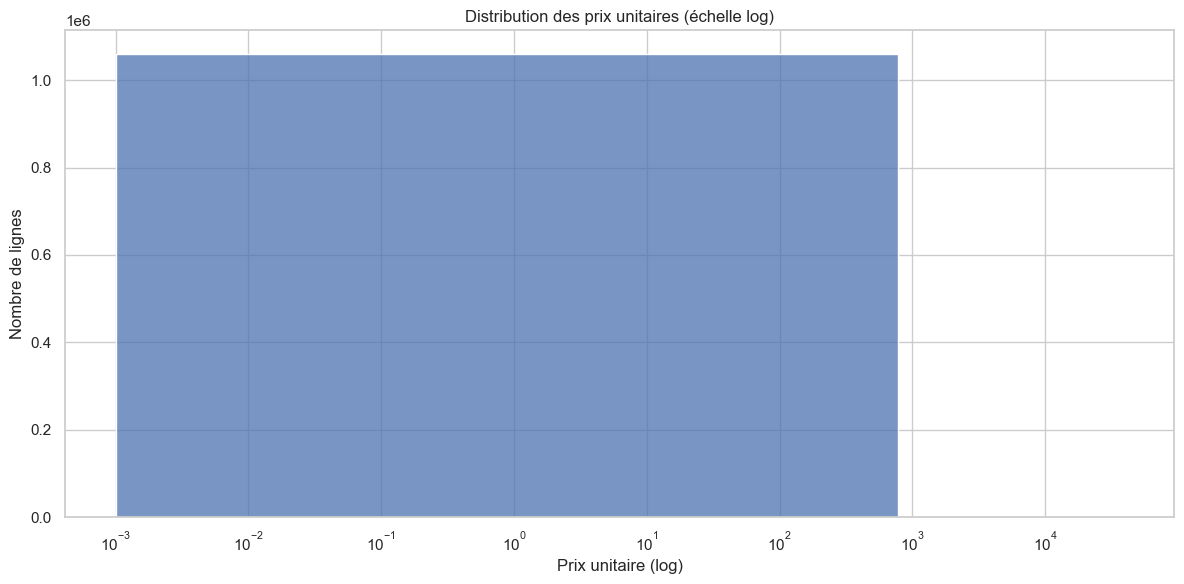

In [24]:
# Graphique 1 : Distribution des prix unitaires (échelle log)
fig, ax = plt.subplots()

# On filtre les prix > 0 pour la vue log
price_pos = df.loc[df["Price"] > 0, "Price"]

sns.histplot(price_pos, bins=50, ax=ax)
ax.set_xscale("log")
ax.set_title("Distribution des prix unitaires (échelle log)")
ax.set_xlabel("Prix unitaire (log)")
ax.set_ylabel("Nombre de lignes")

plt.tight_layout()
plt.show()


### Graphique 1 — Distribution des prix unitaires (log)

- La distribution des **prix unitaires** est fortement asymétrique, avec une majorité de produits à **faible prix** et une traîne de produits plus chers.
- L’échelle logarithmique permet de mieux visualiser l’ensemble de la distribution et de repérer :
  - des **clusters de prix** (gammes de produits),
  - d’éventuels **prix extrêmes** pouvant correspondre à des erreurs de saisie ou à des produits très premium.
- Ce premier aperçu est utile pour :
  - calibrer les analyses de marge,
  - interpréter les segments RFM à forte valeur.


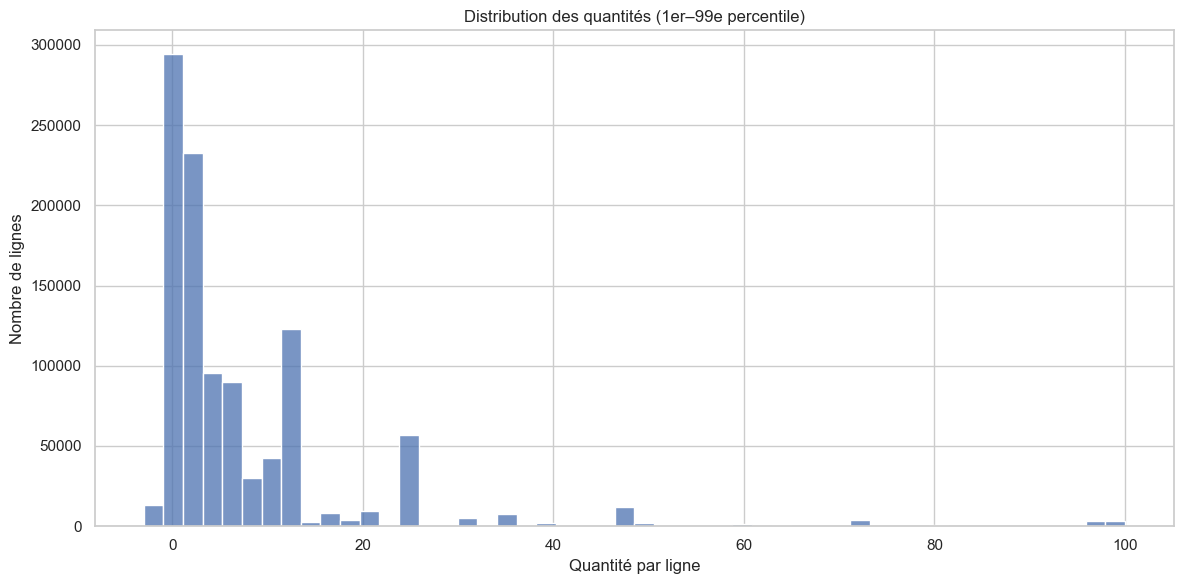

In [25]:
# Graphique 2 : Distribution des quantités (hors outliers extrêmes)
q_low, q_high = df["Quantity"].quantile([0.01, 0.99])

fig, ax = plt.subplots()
sns.histplot(
    df.loc[df["Quantity"].between(q_low, q_high), "Quantity"],
    bins=50,
    ax=ax
)

ax.set_title("Distribution des quantités (1er–99e percentile)")
ax.set_xlabel("Quantité par ligne")
ax.set_ylabel("Nombre de lignes")

plt.tight_layout()
plt.show()


### Graphique 2 — Distribution des quantités

- La plupart des lignes présentent des **quantités faibles à modérées**, ce qui est cohérent avec des commandes B2B régulières.
- La présence de quantités très élevées dans le haut de distribution (coupées ici en 1–99e percentiles) indique des **grosses commandes** ou **réassorts en volume**.
- Ce graphique, couplé à la distinction retours / ventes, aide à :
  - identifier des **retours massifs** (quantités fortement négatives),
  - cibler des clients à activité intense.


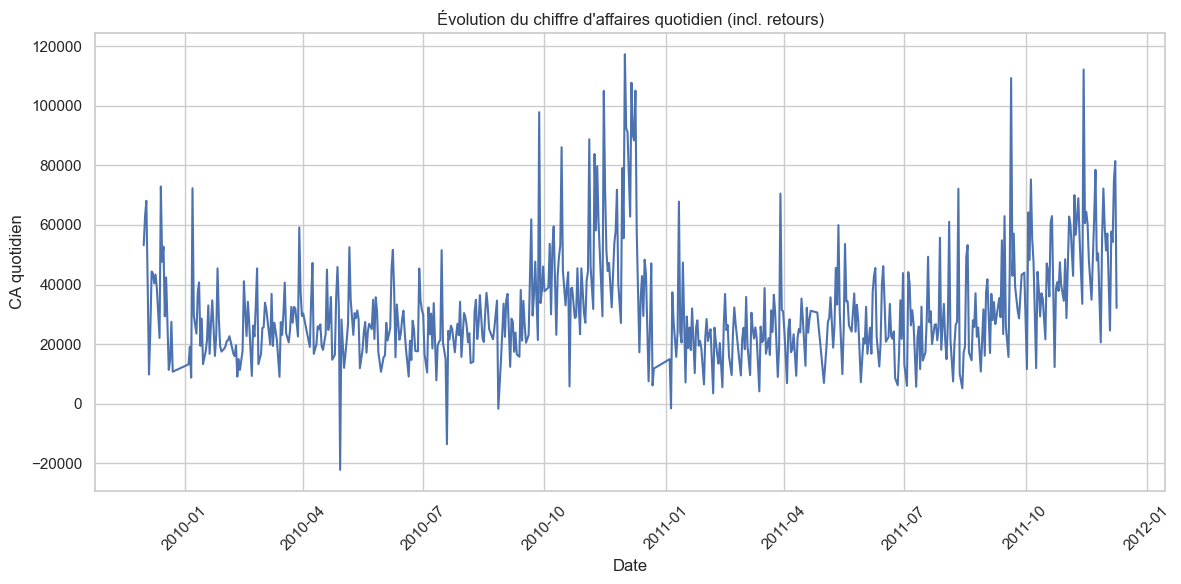

In [26]:
# Graphique 3 : CA quotidien (ventes nettes des retours ou non)
daily_revenue = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
    .sum()
    .rename("Revenue")
    .reset_index()
)

fig, ax = plt.subplots()
ax.plot(daily_revenue["InvoiceDate"], daily_revenue["Revenue"])

ax.set_title("Évolution du chiffre d'affaires quotidien (incl. retours)")
ax.set_xlabel("Date")
ax.set_ylabel("CA quotidien")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Graphique 3 — CA quotidien

- La courbe de **CA quotidien** met en évidence :
  - la **saisonnalité globale** de l’activité (pics et creux récurrents),
  - des **pics spécifiques** (ex. périodes de fêtes, promotions).
- Des **jours avec CA négatif** ou très faible peuvent apparaître en cas de volume important de retours.
- Ce graphique servira de base pour :
  - analyser la **saisonnalité mensuelle** dans les cohortes,
  - contextualiser les changements de rétention ou de politique de remises.


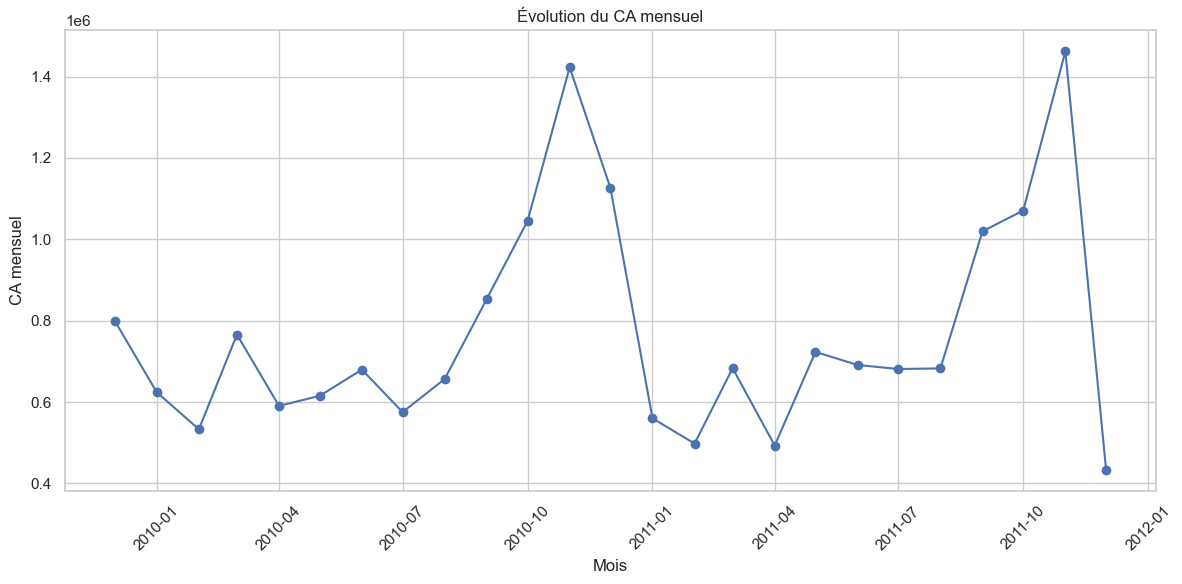

In [27]:
# Graphique 4 : CA mensuel
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)
monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly_revenue["InvoiceDate"], monthly_revenue["Revenue"], marker="o")

ax.set_title("Évolution du CA mensuel")
ax.set_xlabel("Mois")
ax.set_ylabel("CA mensuel")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Graphique 4 — CA mensuel

- Le **CA mensuel** confirme la présence de **24 points temporels** (24 mois) qui serviront de base aux **cohortes mensuelles**.
- On peut identifier :
  - des **tendances de fond** (croissance, stagnation, décroissance),
  - des **saisonnalités mensuelles** (pics récurrents certains mois).
- Ces informations sont cruciales pour distinguer :
  - les effets **cohortes / acquisition**,
  - des effets **purement saisonniers**.


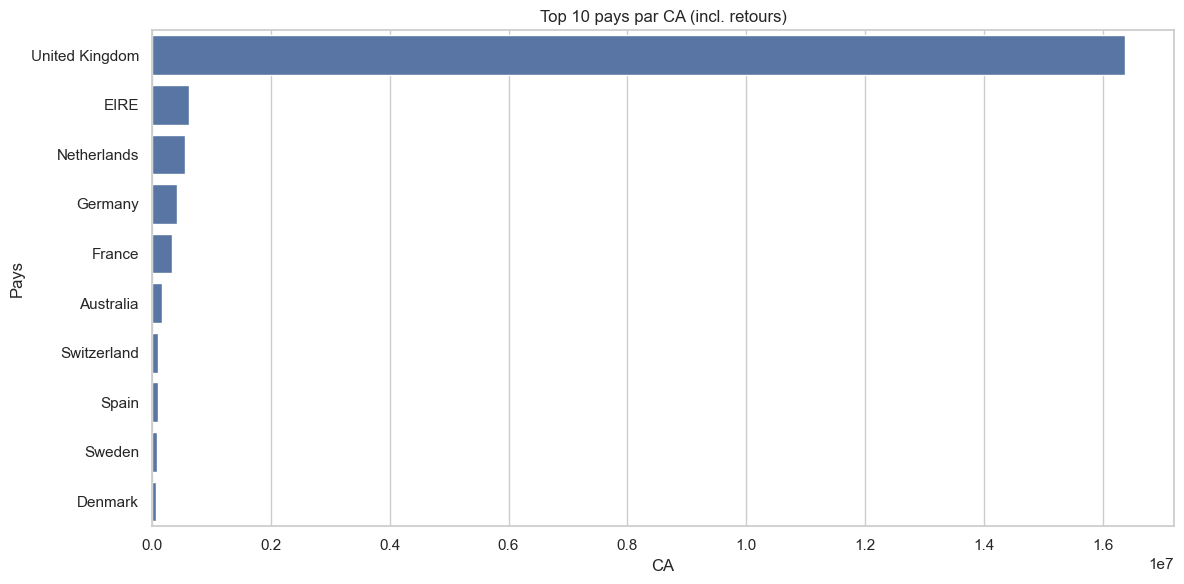

In [28]:
# Graphique 5 : Top pays par CA
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_n = 10
fig, ax = plt.subplots()
sns.barplot(
    data=country_revenue.head(top_n),
    x="Revenue",
    y="Country",
    ax=ax
)

ax.set_title(f"Top {top_n} pays par CA (incl. retours)")
ax.set_xlabel("CA")
ax.set_ylabel("Pays")

plt.tight_layout()
plt.show()


### Graphique 5 — Répartition du CA par pays

- Le **Royaume-Uni (UK)** domine largement le CA, ce qui confirme qu’il s’agit du **marché principal**.
- Les autres pays contribuent de manière plus marginale, mais peuvent représenter :
  - des **opportunités de croissance**,
  - ou des marchés à **fort taux de retours**.
- Pour les analyses de cohortes et de CLV, il sera pertinent :
  - soit de se concentrer sur **UK**,
  - soit de créer des vues filtrées par pays ou regroupements de pays.


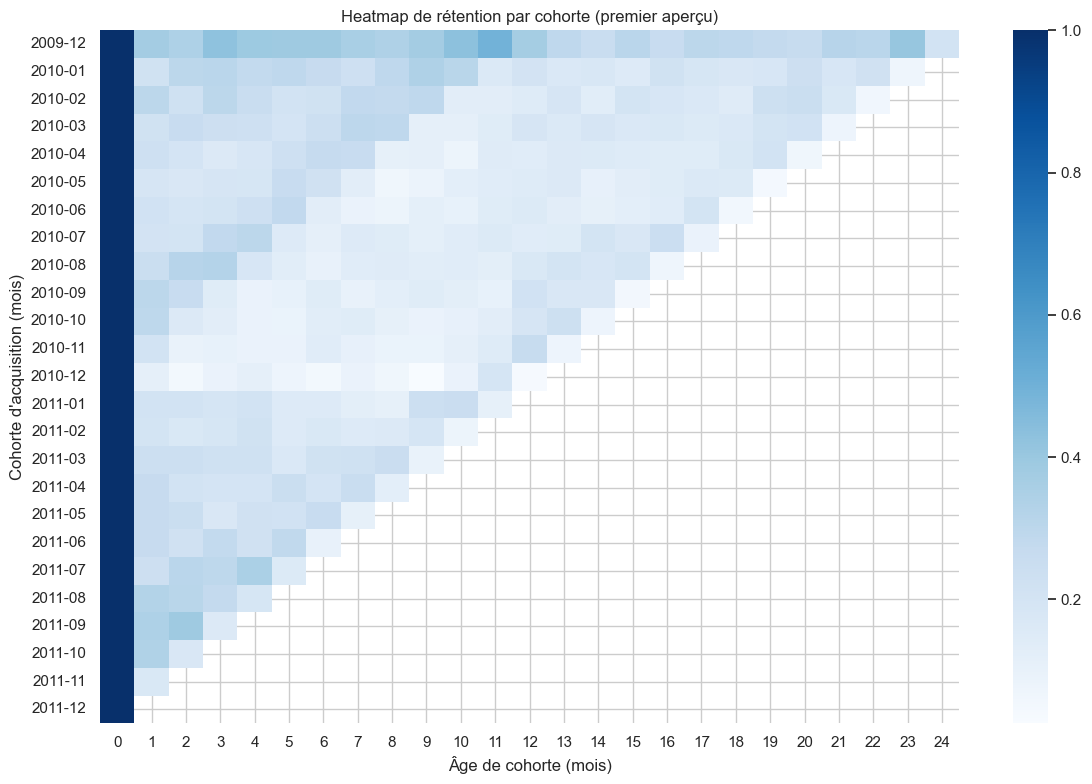

In [30]:
from operator import attrgetter
# Graphique 6 : Première vue cohortes (taux de clients actifs par mois)

# On restreint aux clients identifiés
df_clients = df[df["has_customer"]].copy()

# Cohorte d'acquisition = mois de la 1ère facture du client
first_purchase = (
    df_clients.groupby("Customer_ID")["InvoiceDate"]
    .min()
    .dt.to_period("M")
)
first_purchase.name = "cohort"

df_clients = df_clients.join(first_purchase, on="Customer_ID")

# Mois de la transaction
df_clients["order_period"] = df_clients["InvoiceDate"].dt.to_period("M")

# Index cohortes / périodes
cohort_pivot = (
    df_clients.groupby(["cohort", "order_period"])["Customer_ID"]
    .nunique()
    .reset_index()
)

# Numéro d'âge de cohorte : 0 = mois d'acquisition
cohort_pivot["cohort_index"] = (
    (cohort_pivot["order_period"] - cohort_pivot["cohort"]).apply(attrgetter("n"))
)

# Nombre de clients uniques par cohorte
cohort_sizes = (
    cohort_pivot[cohort_pivot["cohort_index"] == 0]
    .set_index("cohort")["Customer_ID"]
)

# Taux de rétention = nb clients actifs / nb clients à l'acquisition
cohort_pivot = cohort_pivot.join(
    cohort_sizes,
    on="cohort",
    rsuffix="_cohort_size"
)

cohort_pivot["retention_rate"] = (
    cohort_pivot["Customer_ID"] / cohort_pivot["Customer_ID_cohort_size"]
)

# Tableau cohortes (cohort x âge)
cohort_table = cohort_pivot.pivot_table(
    index="cohort",
    columns="cohort_index",
    values="retention_rate"
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cohort_table,
    cmap="Blues",
    annot=False,
    fmt=".0%",
    ax=ax
)

ax.set_title("Heatmap de rétention par cohorte (premier aperçu)")
ax.set_xlabel("Âge de cohorte (mois)")
ax.set_ylabel("Cohorte d'acquisition (mois)")

plt.tight_layout()
plt.show()


### Graphique 6 — Heatmap de rétention par cohorte (aperçu)

- Chaque **ligne** représente une cohorte d’acquisition (mois d’entrée des clients).
- Chaque **colonne** représente l’**âge de cohorte** (M+0, M+1, M+2, …).
- Les cellules montrent un **taux de rétention** (part de clients actifs encore présents à cet âge).
- On observe généralement :
  - une forte **chute entre M+0 et M+1**,
  - puis une stabilisation sur quelques mois.
- Ce premier aperçu confirme que le dataset est adapté à :
  - une analyse fine de la **rétention par cohorte**,
  - le calcul d’une **CLV empirique** par âge de cohorte.


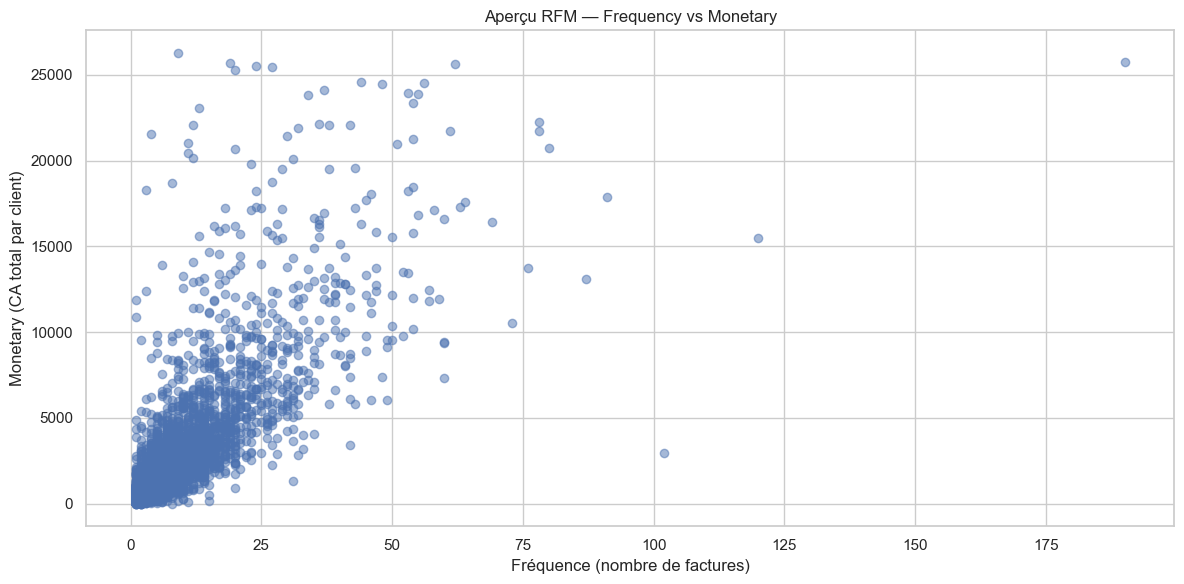

In [31]:
# Graphique 7 : Première vue RFM (scatter Monetary vs Frequency)

# On se place à la date max du dataset comme "référence"
snapshot_date = df_clients["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_clients.groupby("Customer_ID").agg(
        recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        frequency=("Invoice", "nunique"),
        monetary=("Revenue", "sum"),
    )
    .reset_index()
)

# On filtre les valeurs extrêmes pour une meilleure lisibilité
rfm_filtered = rfm[
    (rfm["monetary"] > 0) &
    (rfm["monetary"] <= rfm["monetary"].quantile(0.99))
]

fig, ax = plt.subplots()
scatter = ax.scatter(
    rfm_filtered["frequency"],
    rfm_filtered["monetary"],
    alpha=0.5
)

ax.set_title("Aperçu RFM — Frequency vs Monetary")
ax.set_xlabel("Fréquence (nombre de factures)")
ax.set_ylabel("Monetary (CA total par client)")

plt.tight_layout()
plt.show()


### Graphique 7 — Aperçu RFM

- L’axe **x** représente la **fréquence** (nombre de factures par client).
- L’axe **y** représente le **CA cumulé** par client (`Monetary`).
- Ce nuage de points met en évidence :
  - un grand nombre de **petits clients occasionnels** (faible frequency & monetary),
  - quelques clients à **forte valeur** (haut monetary, parfois combiné à une fréquence élevée).
- Ce premier RFM servira de base à :
  - la définition des **scores RFM (1–5)**,
  - la création de **segments marketing** (Champions, Loyaux, À risque, etc.).


## E — Synthèse & pistes pour la suite

1. **Structure & qualité des données**
   - Le dataset présente une structure classique de détail de factures avec retours explicites via `Quantity < 0`.
   - Les **NA sur `Customer_ID`** imposent de restreindre les analyses client, mais la masse de données reste suffisante.
   - La **granularité temporelle à la minute** permet des analyses fines de séquences d’achat si nécessaire.

2. **Insights exploratoires**
   - **Prix** : distribution très asymétrique, avec une majorité de produits à faible prix.
   - **Quantités** : nombreuses petites commandes, mais aussi des commandes B2B très volumineuses.
   - **Saisonnalité** : variation marquée du CA quotidien et mensuel, à relier aux cohortes.
   - **Pays** : UK est le marché dominant, ce qui justifie de se concentrer d’abord sur ce périmètre.
   - **Cohortes** : la heatmap de rétention montre une décroissance typique, exploitable pour la CLV.
   - **RFM** : la population de clients se répartit entre petits clients et quelques gros contributeurs.

3. **Implications pour les étapes suivantes**
   - Construire un **pipeline de préparation** dans `/utils` :
     - filtrage des clients avec `Customer_ID` non NA,
     - gestion explicite des retours (inclure / exclure / neutraliser),
     - création systématique des variables dérivées (Revenue, cohortes, RFM).
   - Préparer les modules analytiques :
     - **cohortes** : rétention, CA par âge, CLV empirique,
     - **RFM** : scoring, labellisation segments,
     - **CLV** : approche empirique et paramétrique,
     - **simulation** : scénarios sur rétention, marge, remises.

Ce notebook constitue la **base de référence** pour toute la suite du projet (préprocessing, modules analytiques, app Streamlit).
